## Task 2

In [20]:
import torch
import torch.nn as nn
import pandas as pd

In [21]:
df = pd.read_csv("binary_classification_moons.csv")
df.head()

,X1,X2,label
0,-0.009332,0.390981,1
1,0.954574,-0.473756,1
2,0.918526,-0.425196,1
3,0.412768,-0.376385,1
4,-0.845320,0.528799,0


In [22]:
df.describe()

,X1,X2,label
count,1000.000000,1000.000000,1000.00000
mean,0.499552,0.249196,0.50000
std,0.867371,0.494822,0.50025
min,-1.061751,-0.571697,0.00000
25%,-0.019860,-0.216408,0.00000
50%,0.502008,0.248686,0.50000
75%,1.020851,0.694288,1.00000
max,2.064637,1.042677,1.00000


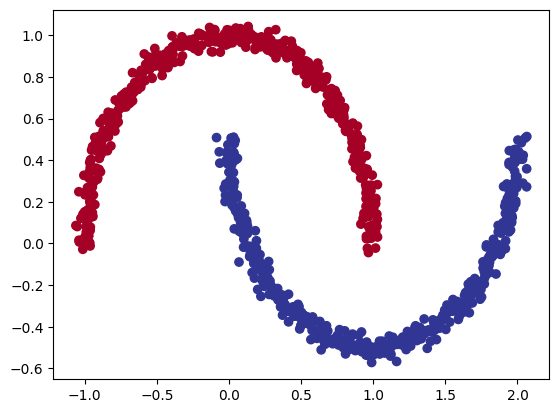

In [23]:
# Visualize with a plot
import matplotlib.pyplot as plt
plt.scatter(
            x=df.X1,
            y=df.X2,
            c=df.label,
            cmap=plt.cm.RdYlBu
            );

In [24]:
# vectorizing X1 and X2 into a single tensor/nparray

X = df[['X1', 'X2']].values
y = df['label'].values

In [25]:
print(f"First 5 X features:\n{X[:5]}")
print(f"\nFirst 5 y labels:\n{y[:5]}")

First 5 X features:
[[-0.00933187  0.39098105]
 [ 0.95457387 -0.47375583]
 [ 0.9185256  -0.42519648]
 [ 0.41276802 -0.37638459]
 [-0.84532016  0.52879908]]

First 5 y labels:
[1 1 1 1 0]


In [26]:
# Check the shapes of our features and labels
X.shape, y.shape

((1000, 2), (1000,))

In [27]:
# Turn data into tensors
# Otherwise this causes issues with computations later on
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# View the first five samples
X[:5], y[:5]

C:\Users\kdhak\AppData\Local\Temp\ipykernel_10876\3007094934.py:4: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  y = torch.from_numpy(y).type(torch.float)


(tensor([[-0.0093,  0.3910],
         [ 0.9546, -0.4738],
         [ 0.9185, -0.4252],
         [ 0.4128, -0.3764],
         [-0.8453,  0.5288]]),
 tensor([1., 1., 1., 1., 0.]))

In [28]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2, # 20% test, 80% train
                                                    random_state=42,
                                                    stratify=y) # make the random split reproducible

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [29]:
# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [30]:
# 1. Construct a model class that subclasses nn.Module
class ModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        # 2. Create 2 nn.Linear layers capable of handling X and y input and output shapes
        self.layer_1 = nn.Linear(in_features=2, out_features=5) # takes in 2 features (X), produces 5 features
        self.layer_2 = nn.Linear(in_features=5, out_features=1) # takes in 5 features, produces 1 feature (y)

    # 3. Define a forward method containing the forward pass computation
    def forward(self, x):
        # Return the output of layer_2, a single feature, the same shape as y
        return self.layer_2(self.layer_1(x)) # computation goes through layer_1 first then the output of layer_1 goes through layer_2

# 4. Create an instance of the model and send it to target device
model_0 = ModelV0().to(device)
model_0

ModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [31]:
model = model_0

In [32]:
# Make predictions with the model
untrained_preds = model(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(y_test)}, Shape: {y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200])

First 10 predictions:
tensor([[ 0.2025],
        [ 0.0363],
        [ 0.0304],
        [ 0.1110],
        [ 0.3176],
        [ 0.2158],
        [ 0.6210],
        [ 0.2655],
        [ 0.3102],
        [-0.0067]], grad_fn=<SliceBackward0>)

First 10 test labels:
tensor([1., 0., 0., 0., 1., 1., 1., 1., 0., 0.])


In [15]:
# Create a loss function
# loss_fn = nn.BCELoss() # BCELoss = no sigmoid built-in
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=model.parameters(),
                            lr=0.1)

In [16]:
# View the frist 5 outputs of the forward pass on the test data
y_logits = model(X_test.to(device))[:5]
y_logits

tensor([[0.5030],
        [0.7345],
        [0.7392],
        [0.6600],
        [0.3300]], grad_fn=<SliceBackward0>)

In [17]:
# Use sigmoid on model logits
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.6232],
        [0.6758],
        [0.6768],
        [0.6593],
        [0.5818]], grad_fn=<SigmoidBackward0>)

In [18]:
# Find the predicted labels (round the prediction probabilities)
y_preds = torch.round(y_pred_probs)

# In full
y_pred_labels = torch.round(torch.sigmoid(model(X_test.to(device))[:5]))

# Check for equality
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# Get rid of extra dimension
y_preds.squeeze()

tensor([True, True, True, True, True])


tensor([1., 1., 1., 1., 1.], grad_fn=<SqueezeBackward0>)

In [19]:
y_test[:5]

tensor([1., 0., 0., 0., 1.])

In [20]:
torch.manual_seed(42)

# Set the number of epochs
epochs = 100

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

In [21]:
torch.manual_seed(42)

# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

# Set the number of epochs
epochs = 100

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Build training and evaluation loop
train_losses = []
acc_list = []
test_losses = []
test_acc = []

for epoch in range(epochs):
    ### Training
    model.train()

    # 1. Forward pass
    y_logits = model(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> prediction probabilities -> prediction labels

    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # 2. Calculate test loss and accuracy
        test_loss = loss_fn(test_logits, y_test)
        test_acc_val = accuracy_fn(y_true=y_test, y_pred=test_pred)

    # Print out what's happening
    if epoch % 10 == 0:
        train_losses.append(loss.item())
        acc_list.append(acc)
        test_losses.append(test_loss.item())
        test_acc.append(test_acc_val)
        print(f"Epoch: {epoch} | Train Loss: {loss:.5f} | Train Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc_val:.2f}%")

print("\nTraining complete!")

Epoch: 0 | Train Loss: 0.80212 | Train Acc: 50.00% | Test Loss: 0.79233 | Test Acc: 50.00%
Epoch: 10 | Train Loss: 0.69794 | Train Acc: 50.00% | Test Loss: 0.68913 | Test Acc: 50.00%
Epoch: 20 | Train Loss: 0.62349 | Train Acc: 75.75% | Test Loss: 0.61203 | Test Acc: 80.50%
Epoch: 30 | Train Loss: 0.55350 | Train Acc: 84.62% | Test Loss: 0.53819 | Test Acc: 88.50%
Epoch: 40 | Train Loss: 0.48670 | Train Acc: 84.00% | Test Loss: 0.46769 | Test Acc: 88.00%
Epoch: 50 | Train Loss: 0.43032 | Train Acc: 82.88% | Test Loss: 0.40822 | Test Acc: 87.50%
Epoch: 60 | Train Loss: 0.38837 | Train Acc: 82.88% | Test Loss: 0.36358 | Test Acc: 86.50%
Epoch: 70 | Train Loss: 0.35915 | Train Acc: 83.25% | Test Loss: 0.33186 | Test Acc: 86.00%
Epoch: 80 | Train Loss: 0.33888 | Train Acc: 83.88% | Test Loss: 0.30932 | Test Acc: 86.00%
Epoch: 90 | Train Loss: 0.32435 | Train Acc: 84.38% | Test Loss: 0.29278 | Test Acc: 86.00%

Training complete!


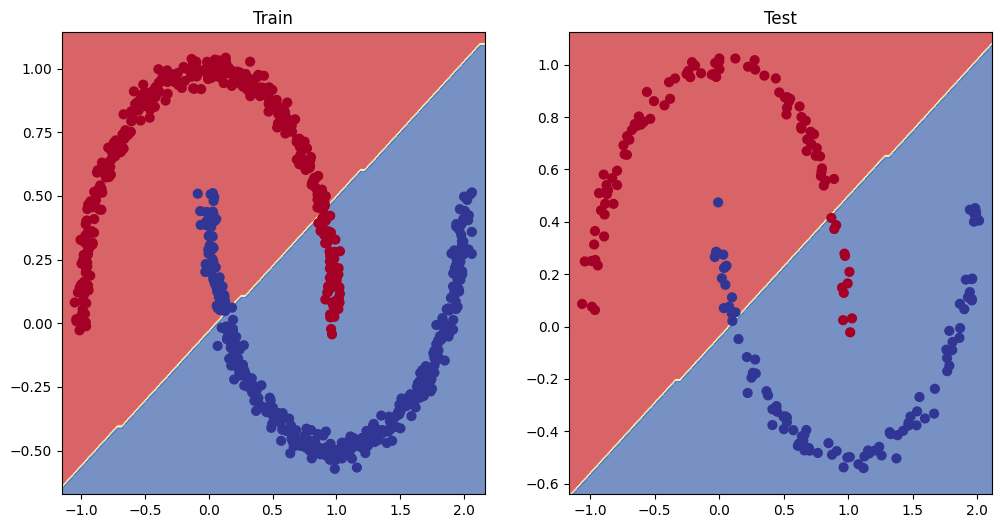

In [22]:
import numpy as np

def plot_decision_boundary(model, X, y):
    # Put everything to CPU (works with CPU and GPU inputs)
    X, y = X.to("cpu"), y.to("cpu")

    # Setup prediction boundaries and meshgrid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    # Make features for prediction
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Change predictions shape for plotting
    y_pred = torch.round(torch.sigmoid(y_logits)).squeeze()

    # Plotting
    plt.contourf(xx, yy, y_pred.reshape(xx.shape).cpu().numpy(), cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0].cpu().numpy(), X[:, 1].cpu().numpy(), c=y.cpu().numpy(), s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

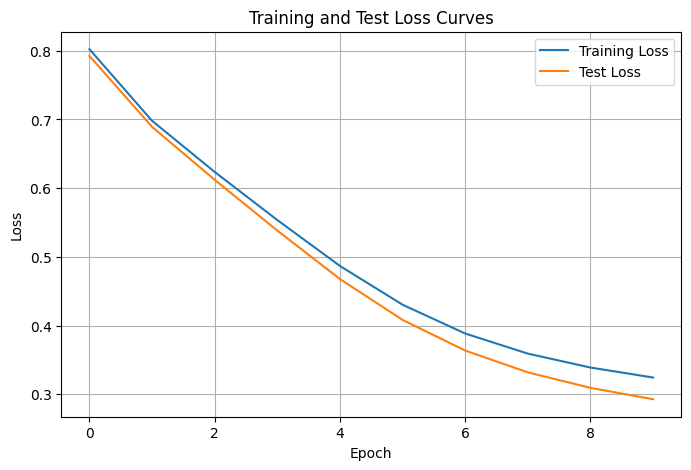

In [23]:

import matplotlib.pyplot as plt

def plot_loss_curves(train_losses, test_losses):
    """
    Plots training and testing loss curves.

    Args:
        train_losses (list): Loss values from training
        test_losses (list): Loss values from testing
    """
    epochs = range(len(train_losses))

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_losses, label="Training Loss")
    plt.plot(epochs, test_losses, label="Test Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Test Loss Curves")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_loss_curves(train_losses, test_losses)

In [24]:
class ModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU() # Add ReLU activation function

    def forward(self, x): # note: always make sure forward is spelt correctly!
        # Creating a model like this is the same as below, though below
        # generally benefits from speedups where possible.
        # z = self.layer_1(x)
        # z = self.layer_2(z)
        # z = self.layer_3(z)
        # return z
        # Now with ReLU activations in between the layers
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_1 = ModelV1().to(device)
model_1

ModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [25]:
model = model_1
epochs = 2000

# Create a loss function
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=model.parameters(),
                            lr=0.1)

Epoch: 0 | Train Loss: 0.69550 | Train Acc: 37.12% | Test Loss: 0.69398 | Test Acc: 49.50%
Epoch: 100 | Train Loss: 0.40106 | Train Acc: 80.12% | Test Loss: 0.37510 | Test Acc: 83.00%
Epoch: 200 | Train Loss: 0.24124 | Train Acc: 89.00% | Test Loss: 0.20533 | Test Acc: 91.50%
Epoch: 300 | Train Loss: 0.19199 | Train Acc: 91.62% | Test Loss: 0.15837 | Test Acc: 93.00%
Epoch: 400 | Train Loss: 0.14695 | Train Acc: 94.12% | Test Loss: 0.12286 | Test Acc: 96.50%
Epoch: 500 | Train Loss: 0.09915 | Train Acc: 96.25% | Test Loss: 0.08473 | Test Acc: 98.00%
Epoch: 600 | Train Loss: 0.06205 | Train Acc: 99.00% | Test Loss: 0.05382 | Test Acc: 99.00%
Epoch: 700 | Train Loss: 0.03974 | Train Acc: 99.88% | Test Loss: 0.03484 | Test Acc: 99.50%
Epoch: 800 | Train Loss: 0.02740 | Train Acc: 100.00% | Test Loss: 0.02426 | Test Acc: 100.00%
Epoch: 900 | Train Loss: 0.02015 | Train Acc: 100.00% | Test Loss: 0.01801 | Test Acc: 100.00%
Epoch: 1000 | Train Loss: 0.01559 | Train Acc: 100.00% | Test Loss: 

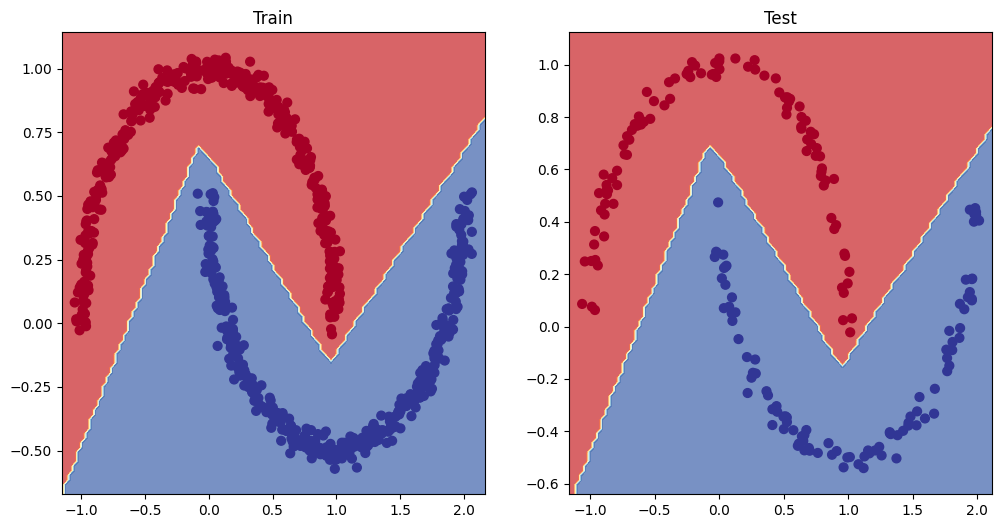

In [26]:
torch.manual_seed(42)

# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

# Put data to target device (if not already done, important for fresh runs)
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Build training and evaluation loop
train_losses = []
acc_list = []
test_losses = []
test_acc = []

for epoch in range(epochs):
    ### Training
    model.train()

    # 1. Forward pass
    y_logits = model(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> prediction probabilities -> prediction labels

    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # 2. Calculate test loss and accuracy
        test_loss = loss_fn(test_logits, y_test)
        test_acc_val = accuracy_fn(y_true=y_test, y_pred=test_pred)

    # Print out what's happening
    if epoch % 100 == 0 or epoch == epochs - 1:
        train_losses.append(loss.item())
        acc_list.append(acc)
        test_losses.append(test_loss.item())
        test_acc.append(test_acc_val)
        print(f"Epoch: {epoch} | Train Loss: {loss:.5f} | Train Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc_val:.2f}%")

print("\nTraining complete!")

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)


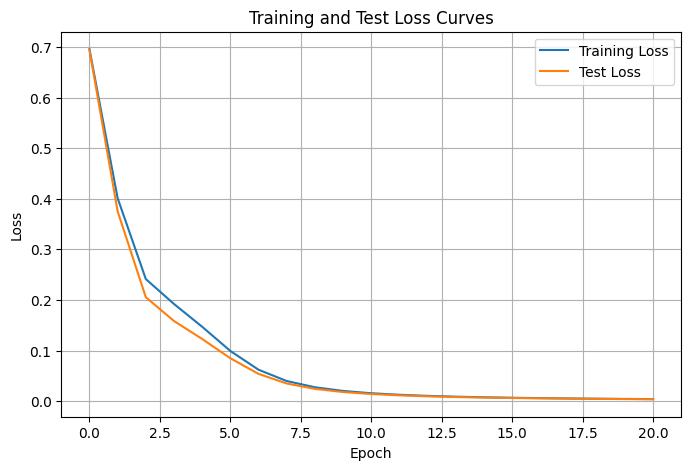

In [28]:
plot_loss_curves(train_losses, test_losses)